In [10]:
BATCH_SIZE = 32

WIDTH = 9
HEIGHT = 9
NUM_AGENTS = 4
LEARNING_RATE = 0.0001
CONV_CHANNELS = [32, 64, 64]
KERNEL_SIZE = 3

MODEL_SAVE_PATH = f"reward_model_{WIDTH}x{HEIGHT}_{NUM_AGENTS}a.pt"

DEBUG = False

In [11]:
import sys
sys.path.append('../../../')
from tadd_helpers.env_functions import State
import pickle
import numpy as np
from models.cnn import CoordCNNDecentralized
from matplotlib import pyplot as plt
from tqdm import tqdm
from pathlib import Path
import torch

import pandas as pd
import seaborn as sns
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [12]:
MODEL_SAVE_PATH = Path(MODEL_SAVE_PATH)
if not MODEL_SAVE_PATH.exists():
    MODEL_SAVE_PATH.mkdir(parents=True)


In [13]:
def get_decentralized_reward_when_picked(picked: bool, picker_index, picker_pos, all_agents) -> dict[int, float]:
    """Return decentralized reward of all agents

    Args:
        picked (bool): Whether an agent has picked an apple
        picker_index: _description_
        picker_pos: _description_
        all_agents: dict[int, tuple]: Mapping from agent index to (x, y) position
    """
    res: dict[int, float] = {}
    
    if not picked:
        for agent_idx in all_agents.keys():
            res[agent_idx] = 0.0
        return res

    res[picker_index] = -1

    # Calculate distances from ALL agents to the picker
    all_agent_positions = np.array(list(all_agents.values()))
    distances = np.linalg.norm(all_agent_positions - np.array(picker_pos), axis=1)
    sum_of_distances = np.sum(distances)
    
    for agent_idx in all_agents.keys():
        if agent_idx == picker_index:
            continue
        agent_pos = all_agents[agent_idx]
        agent_distance = np.linalg.norm(np.array(agent_pos) - np.array(picker_pos))
        if sum_of_distances == 0:
            res[agent_idx] = 0.0
        else:
            res[agent_idx] = 2 * agent_distance / sum_of_distances
    return res

def get_picker_index_and_pos_from_state(state: State):
    """Extract the picker index and position from the state. 

    Args:
        state (State): The current environment state
    Returns:
        picked: bool: Whether an agent has picked an apple
        picker_index (int): The index of the picker agent
        picker_pos (tuple): The (x, y) position of the picker agent 
    """
    picked = False
    picker_index = -1
    picker_pos = (-1, -1)
    for agent_idx, agent_pos in state._agents.items():
        # check if the agent_pos is in the apples nd array
        if state._apples[agent_pos] >= 1:
            picked = True
            picker_index = agent_idx
            picker_pos = agent_pos
            break
    return picked, picker_index, picker_pos

def get_decentralized_reward_from_state(state: State) -> dict[int, float]:
    """Calculate the decentralized reward for the self-agent based on the state.

    Args:
        state (State): The current environment state
    Returns:
        dict[int, float]: The decentralized rewards for all agents
    """
    picked, picker_index, picker_pos = get_picker_index_and_pos_from_state(state)
    all_agents = state._agents
    rewards = get_decentralized_reward_when_picked(picked, picker_index, picker_pos, all_agents)
    return rewards

In [14]:
states: list[State] = []
states_file_path = f"centralized_model{WIDTH}x{HEIGHT}_agents{NUM_AGENTS}/trained_states_centralized.pkl"
with open(states_file_path, "rb") as f:
    states = pickle.load(f)

In [15]:
import random

# Buckets for data
data_zero_reward = []
data_positive_reward = []
data_negative_reward = []

print("Processing states...")
# Assuming 'states' is your loaded list of State objects
for state in tqdm(states[:40000]): # Limit to 10k states for speed, that's plenty
    rewards = get_decentralized_reward_from_state(state)
    raw_state = {"agents": state.agents, "apples": state.apples}
    
    for agent_id, r in rewards.items():
        # Store tuple: (raw_state_dict, agent_position, reward)
        item = (raw_state, state.agent_position(agent_id), r)
        
        if r == 0:
            data_zero_reward.append(item)
        elif r == -1:
            data_negative_reward.append(item)
        else:
            data_positive_reward.append(item)

print(f"Zeros: {len(data_zero_reward)}")
print(f"Pickers (-1): {len(data_negative_reward)}")
print(f"Distances (>0): {len(data_positive_reward)}")

# Combine interesting cases
data_interesting = data_positive_reward + data_negative_reward

Processing states...


100%|██████████| 40000/40000 [00:00<00:00, 50878.64it/s]

Zeros: 107824
Pickers (-1): 13044
Distances (>0): 39132


Starting Supervised Training on cuda...


100%|██████████| 1000/1000 [00:13<00:00, 73.34it/s]


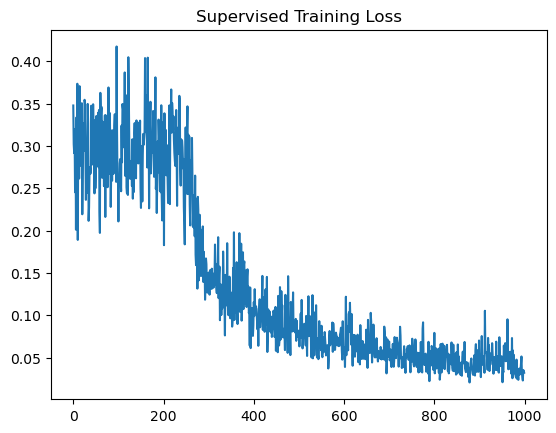

In [ ]:
# Init Model
model = CoordCNNDecentralized(WIDTH, HEIGHT, 0.001) # Slightly higher LR for supervised

# --- FIX 2: Move Model to Device ---
model.to(device) 
model.train()

BATCH_SIZE = 64
NUM_BATCHES = 1000 # Total update steps

losses = []

print(f"Starting Supervised Training on {device}...")

for i in tqdm(range(NUM_BATCHES)):
    model.optimizer.zero_grad()
    
    batch_states = []
    batch_rewards = []
    
    # 1. Create Balanced Batch (50% Zero, 50% Non-Zero)
    for _ in range(BATCH_SIZE // 2):
        # Sample Zero
        s, pos, r = random.choice(data_zero_reward)
        batch_states.append(model.raw_state_to_nn_input(s, agent_pos=pos))
        batch_rewards.append(r)
        
        # Sample Interesting (Positive OR Negative)
        s, pos, r = random.choice(data_interesting)
        batch_states.append(model.raw_state_to_nn_input(s, agent_pos=pos))
        batch_rewards.append(r)
        
    # 2. Manual Train Step
    # Using torch.tensor is correct here.
    # Note: We typically use model(x) instead of model.forward(x) in PyTorch
    states_tensor = torch.tensor(np.stack(batch_states), dtype=torch.float32).to(device)
    rewards_tensor = torch.tensor(np.array(batch_rewards), dtype=torch.float32).to(device)
    
    preds = model(states_tensor).squeeze(1)
    loss = torch.nn.functional.mse_loss(preds, rewards_tensor)
    
    loss.backward()
    model.optimizer.step()
    
    losses.append(loss.item())

plt.plot(losses)
plt.title("Supervised Training Loss")
plt.show()

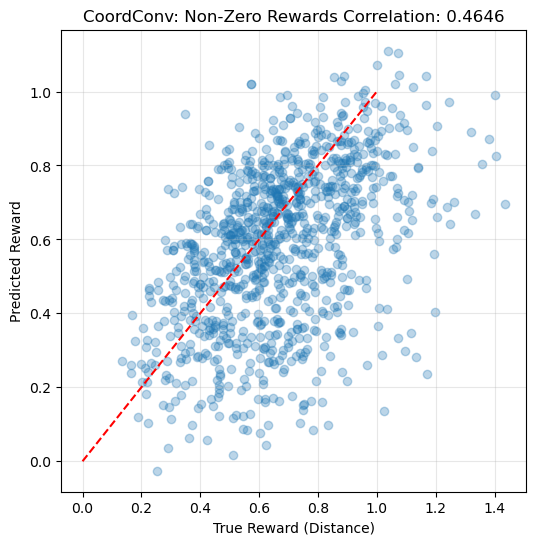

In [21]:
model.eval()
trues = []
preds = []

# Evaluate only on the hard cases (Reward > 0)
eval_set = data_positive_reward[:1000] 

with torch.no_grad():
    for s, pos, r in eval_set:
        processed = model.raw_state_to_nn_input(s, agent_pos=pos)
        
        # --- FIX 3: Send input to device ---
        input_tensor = torch.tensor(processed, dtype=torch.float32).unsqueeze(0).to(device)
        
        pred = model(input_tensor).item()
        
        trues.append(r)
        preds.append(pred)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(trues, preds, alpha=0.3)
# Perfect prediction line
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("True Reward (Distance)")
plt.ylabel("Predicted Reward")
plt.title(f"CoordConv: Non-Zero Rewards Correlation: {np.corrcoef(trues, preds)[0,1]:.4f}")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
MAPE = np.mean(np.abs((np.array(trues) - np.array(preds)) / np.array(trues))) * 100
print(f"Mean Absolute Percentage Error (MAPE) on Non-Zero Rewards: {MAPE:.2f}%")

Mean Absolute Percentage Error (MAPE) on Non-Zero Rewards: 29.29%


: 